<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-5 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Convolution Neural Networks </h2> </html>

<html> <h2 style="font-style:italic; color:blue;"> Task 1 : </h2> </html>

#### Develop and evaluate an image classifier using Convolution Neural Network.

### The Data = CIFAR 10, Multiple Classes datset.

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

ttps://www.cs.toronto.edu/~kriz/cifar.html

Example of using Keras for CNNs. Use a famous data set, the CIFAR-10 dataset which consists of 10 different image types.

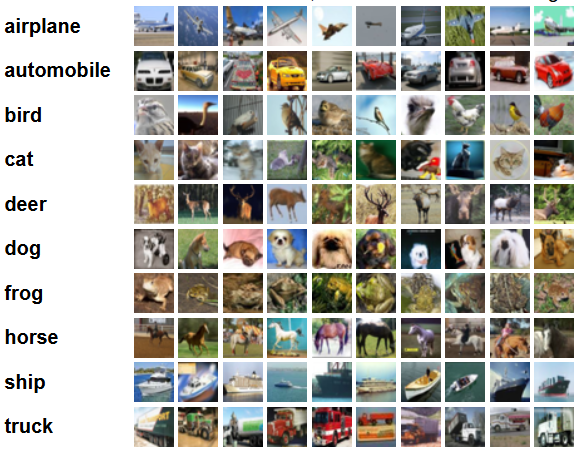

In [1]:
# Your code to import matplotlib, pandas and numpy libraries
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


##### Following code loads the CIFAR 10 datset.

___________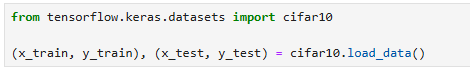

In [2]:
from tensorflow.keras.datasets import cifar10

(x_train,y_train),(x_test,y_test) = cifar10.load_data()

2026-02-26 11:34:08.068239: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 11:34:08.775657: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-26 11:34:11.194078: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/suriya/anaconda3/envs/tf_env/lib/
2026-02-26 11:34:11.194365: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_pl

170498071/170498071 [==============================] - 87s 1us/step


In [3]:
# Source - https://stackoverflow.com/a/38019608
# Posted by Yao Zhang, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-19, License - CC BY-SA 4.0
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
#pip install tensorflow[and-cuda]

Num GPUs Available:  1


2026-02-26 11:35:48.493304: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-26 11:35:48.537436: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-26 11:35:48.539057: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [4]:
# Your code to print shapes of training and test data. Check how the data looks

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [5]:
# Your code to print the shape of one image

x_train[1].shape

(32, 32, 3)

(32, 32, 3)

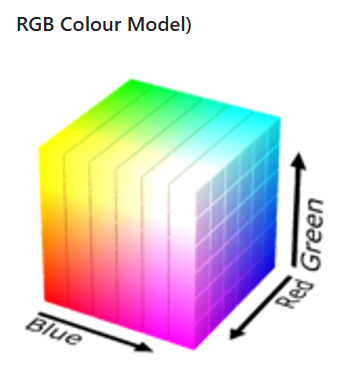

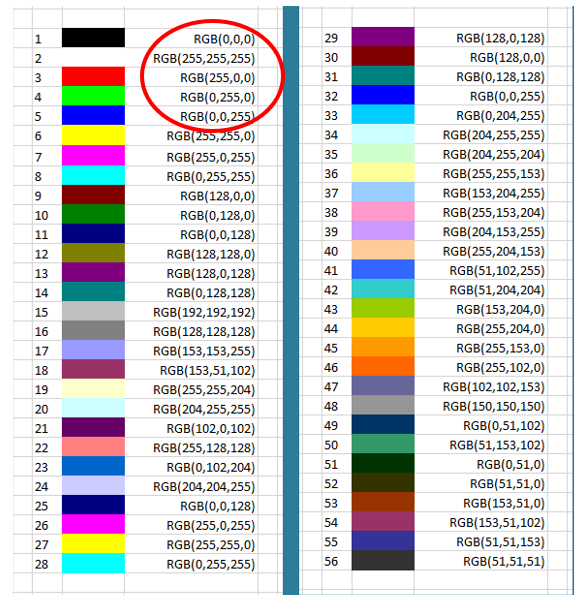

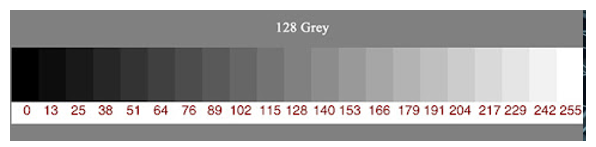

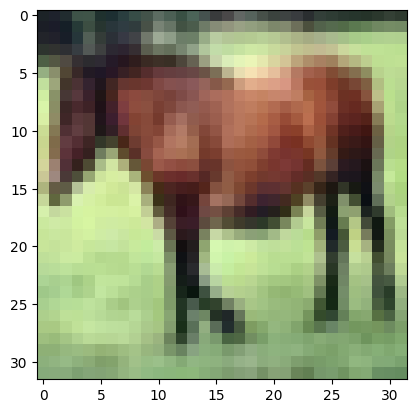

In [6]:
# Your code to show any sample image in the dataset. Use - plt.imshow()

plt.imshow(x_train[7])


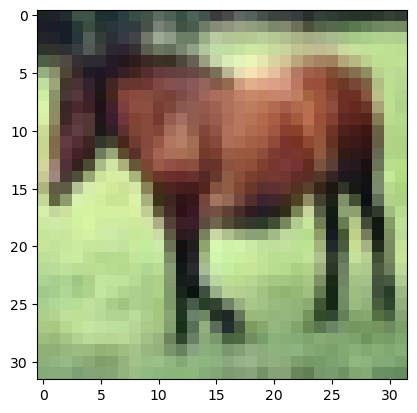

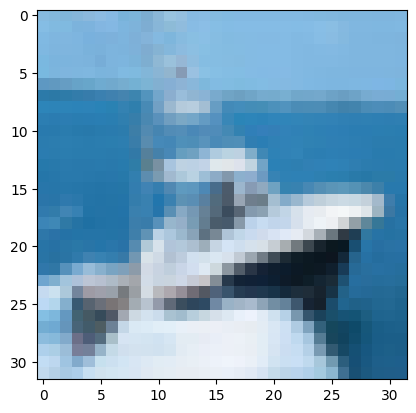

In [7]:
# Show any other image

plt.imshow(x_train[8])


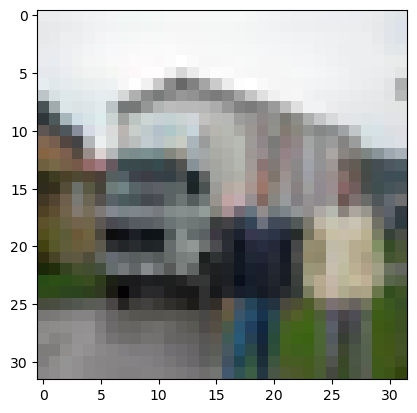

____________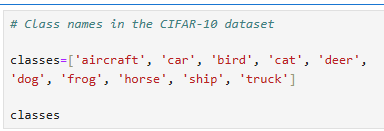

In [8]:
classes=['aircraft' , 'car' ,'bird' , 'cat' ,'deer' , 'dog' , 'frog' ,'horse' , 'ship' , 'truck']
classes

['aircraft',
 'car',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

['aircraft',
 'car',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

______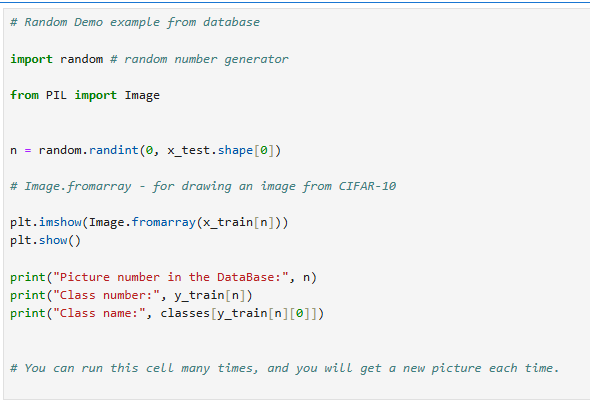

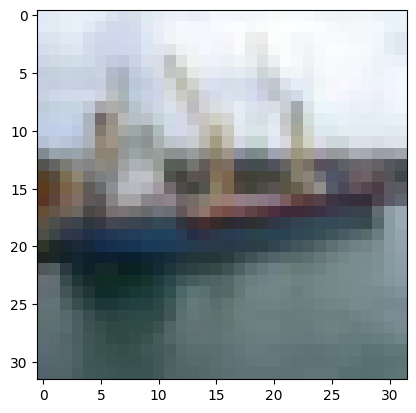

Picture number in the Database: 8665
Class number: [8]
Class name: ship


In [9]:
import random
from PIL import Image

n=random.randint(0 , x_test.shape[0])

plt.imshow(Image.fromarray(x_train[n]))
plt.show()

print("Picture number in the Database:",n)
print("Class number:" ,y_train[n])
print("Class name:" , classes[y_train[n][0]])


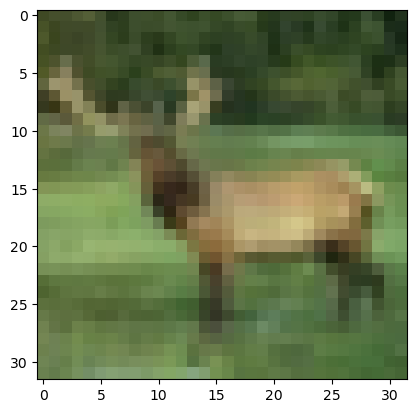

Picture number in the DataBase: 528
Class number: [4]
Class name: deer


## PreProcessing

In [10]:
# Your code to print one image in digitals. Check what pixels look like. 

x_train[0]


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [11]:
# Your code to print the shape of any image i.e particular value in the x_train

x_train[0].shape

(32, 32, 3)

(32, 32, 3)

In [12]:
# Your code to print the maximum value in x_train. Hint - Use .max()

print(x_train.max())

255


255

____________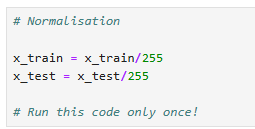

In [13]:
x_train = x_train/255
x_test = x_test/255

__________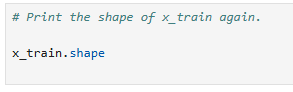

In [14]:
x_train.shape

(50000, 32, 32, 3)

(50000, 32, 32, 3)

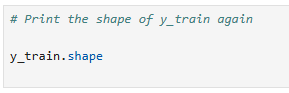

In [15]:
y_train.shape

(50000, 1)

(50000, 1)

## One hot vector encoding.
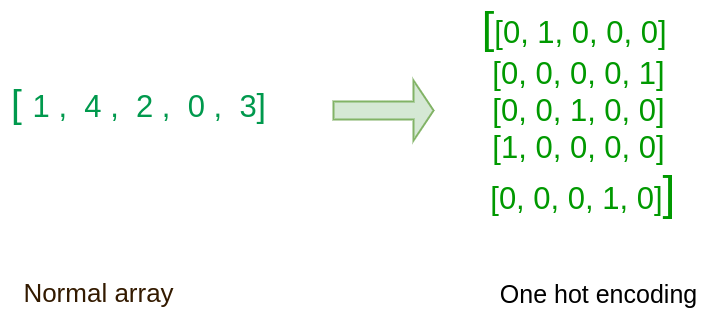


The "to_categorical()" is converting the integer value to binary categorical matrix : https://keras.io/api/utils/python_utils/#to_categorical-functionLinks to an external site.

________________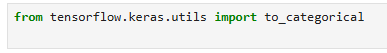

In [16]:
from tensorflow.keras.utils import to_categorical

___________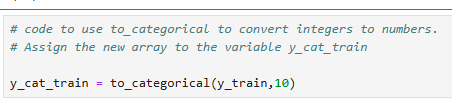

In [17]:
y_cat_train=to_categorical(y_train,10)

In [19]:
# Your code to print the shape of the array y_cat_train

y_cat_train.shape

(50000, 10)

(50000, 10)

In [20]:
# Your code to print any single value in the array y_cat_train and print y_train with the same index.

# Compare the result for better understanding of "to_categorical()"

print(y_train[0])
print(y_cat_train[0])

[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [21]:
# Your code to:
# Convert y_test to the encoded vector in the same manner
# Assign it to the variable y_cat_test

y_cat_test = to_categorical(y_test,10)


____________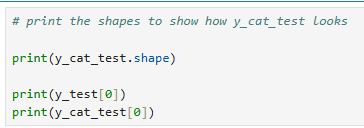

In [22]:
print(y_cat_test.shape)
print(y_test[0])
print(y_cat_test[0])

(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


-----------------

## Creating a CNN Model

_____________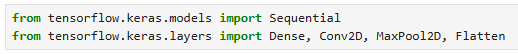

In [23]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense ,Conv2D , MaxPool2D ,Flatten

#### Please read the following links before creating code for the next cell

https://keras.io/api/layers/convolution_layers/convolution2d/
    
https://keras.io/api/layers/pooling_layers/max_pooling2d/

In [24]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (8, 8), activation='relu', input_shape=(32, 32, 3)), 
    layers.Conv2D(32, (6, 6), strides=(1, 1), activation='relu'),          
    layers.MaxPooling2D(pool_size=(2, 2)), 
    
    layers.Conv2D(64, (6, 6), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),  
    
    

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])



2026-02-26 11:36:04.335295: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 11:36:04.337122: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-26 11:36:04.340793: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-26 11:36:04.343610: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zer

__________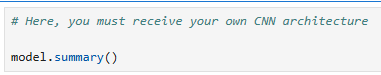

In [27]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 25, 25, 32)        6176      
                                                                 
 conv2d_1 (Conv2D)           (None, 20, 20, 32)        36896     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 10, 10, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 5, 5, 64)          73792     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 2, 2, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 256)               0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,826 (1.70 MB)

 Trainable params: 446,826 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

### We could use early stopping in Keras to break from the training.
### What this does is for successive iterations it monitors the loss. If the loss does not decreases for a certain number of iterations denoted by variable 'patience' then the training stops.
### Following code shows how you can use early stopping.


___________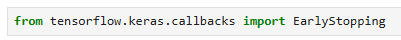

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

__________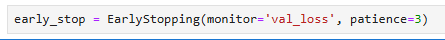

In [29]:
early_stop =EarlyStopping(monitor='val_loss' ,patience=3)

In [30]:
# Your code to compile the models (model.compile). 

# Use 'categorical cross entropy' as the loss function
# and use 'accuracy' as the metrics
# You can use the optimiser of your choice

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


________________________________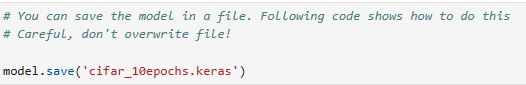

In [31]:
model.save('cifar_10epochs.keras')

In [68]:
# Your code to fit the model (model.fit). 

# Use additional parameter -  callbacks = [early_stop] to enable early stopping. 
# Use 'history' array to save the training parameters for each epoch

# history = ....


______________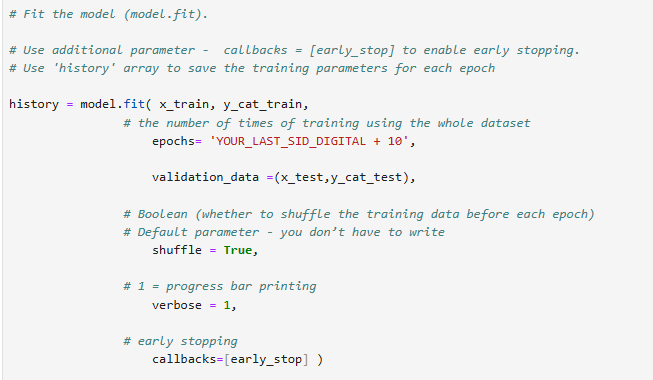

In [32]:
history = model.fit(x_train ,y_cat_train, epochs =14 , validation_data=(x_test,y_cat_test), shuffle =True , verbose=1 ,callbacks =[early_stop])

2026-02-26 11:36:52.482130: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 614400000 exceeds 10% of free system memory.
2026-02-26 11:36:53.566155: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/14


2026-02-26 11:36:58.132494: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8100
2026-02-26 11:37:00.166153: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-02-26 11:37:00.166828: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-02-26 11:37:00.166886: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2026-02-26 11:37:00.167650: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-02-26 11:37:00.167816: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


1563/1563 [==============================] - ETA: 0s - loss: 1.9160 - accuracy: 0.2736

2026-02-26 11:37:21.053151: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.
2026-02-26 11:37:21.286514: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


1563/1563 [==============================] - 29s 13ms/step - loss: 1.9160 - accuracy: 0.2736 - val_loss: 1.6842 - val_accuracy: 0.3723
Epoch 2/14
1563/1563 [==============================] - 19s 12ms/step - loss: 1.6228 - accuracy: 0.4019 - val_loss: 1.5351 - val_accuracy: 0.4408
Epoch 3/14
1563/1563 [==============================] - 19s 12ms/step - loss: 1.5095 - accuracy: 0.4490 - val_loss: 1.4836 - val_accuracy: 0.4599
Epoch 4/14
1563/1563 [==============================] - 19s 12ms/step - loss: 1.4234 - accuracy: 0.4901 - val_loss: 1.3940 - val_accuracy: 0.4989
Epoch 5/14
1563/1563 [==============================] - 19s 12ms/step - loss: 1.3481 - accuracy: 0.5197 - val_loss: 1.3809 - val_accuracy: 0.5139
Epoch 6/14
1563/1563 [==============================] - 19s 12ms/step - loss: 1.2817 - accuracy: 0.5446 - val_loss: 1.3340 - val_accuracy: 0.5341
Epoch 7/14
1563/1563 [==============================] - 19s 12ms/step - loss: 1.2262 - accuracy: 0.5642 - val_loss: 1.2684 - val_accura

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 37ms/step - accuracy: 0.3481 - loss: 1.7774 - val_accuracy: 0.5303 - val_loss: 1.3498
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.5634 - loss: 1.2280 - val_accuracy: 0.5538 - val_loss: 1.2199
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6255 - loss: 1.0565 - val_accuracy: 0.6245 - val_loss: 1.0497
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6674 - loss: 0.9428 - val_accuracy: 0.6840 - val_loss: 0.9512
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7039 - loss: 0.8390 - val_accuracy: 0.6653 - val_loss: 1.0131
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.7268 - loss: 0.7695 - val_accuracy: 0.6328 - val_loss: 1.2476
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.7585 - loss: 0.6951 - val_accuracy: 0.6821 - val_loss: 1.0933


##### You can save the model in a file. Following code shows how to do this.

________________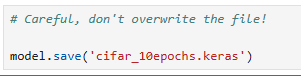

In [33]:
model.save('cifar_10epochs.keras')

##### Yiu can save the loss at every step. Following code shows how to do this. 

___________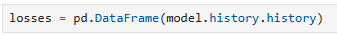

In [34]:
losses =pd.DataFrame(model.history.history)

In [35]:
# You code to print the first few rows of losses.

losses.head(7)


,loss,accuracy,val_loss,val_accuracy
0,1.915974,0.27364,1.684171,0.3723
1,1.622781,0.40190,1.535073,0.4408
2,1.509475,0.44904,1.483631,0.4599
3,1.423379,0.49008,1.393958,0.4989
4,1.348115,0.51974,1.380911,0.5139
5,1.281715,0.54460,1.334011,0.5341
6,1.226210,0.56416,1.268405,0.5542


,accuracy,loss,val_accuracy,val_loss
0,0.43480,1.560612,0.5303,1.349832
1,0.57198,1.201473,0.5538,1.219868
2,0.62928,1.049085,0.6245,1.049745
3,0.66792,0.944133,0.6840,0.951214
4,0.70052,0.851300,0.6653,1.013123
5,0.72508,0.783289,0.6328,1.247608
6,0.74762,0.724635,0.6821,1.093254


#### Visualise a plot between accuracy vs val_accuracy for all steps.

#### x axis will have the steps (epochs) 
#### y axis will have accuracy and val_accuracy 


_________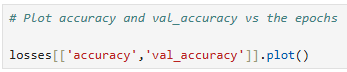

<Axes: >

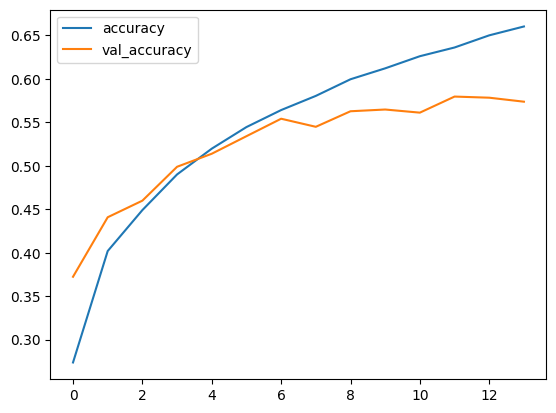

In [36]:
losses[['accuracy','val_accuracy']].plot()

<Axes: >

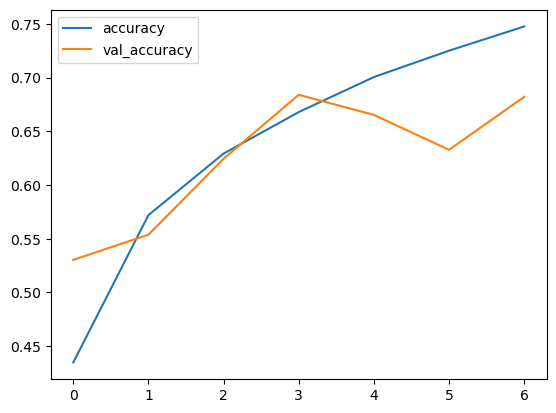

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

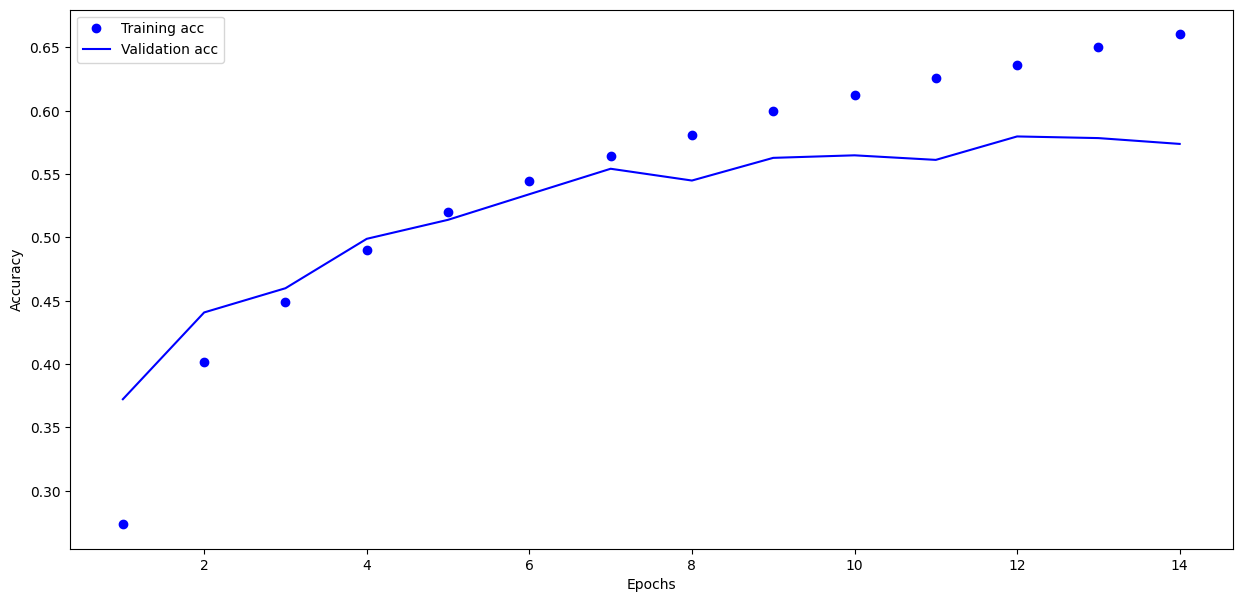

In [37]:
# Plot accuracy and val_accuracy for the neural network training process in more detail

history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

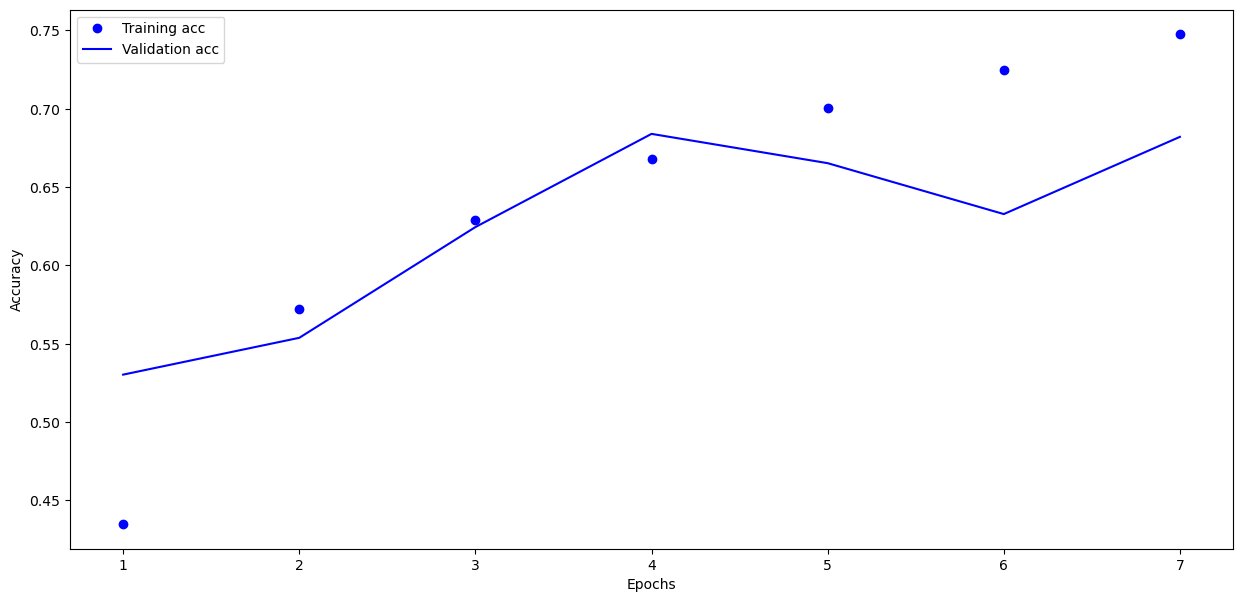

__________________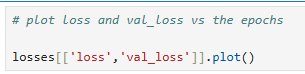

<Axes: >

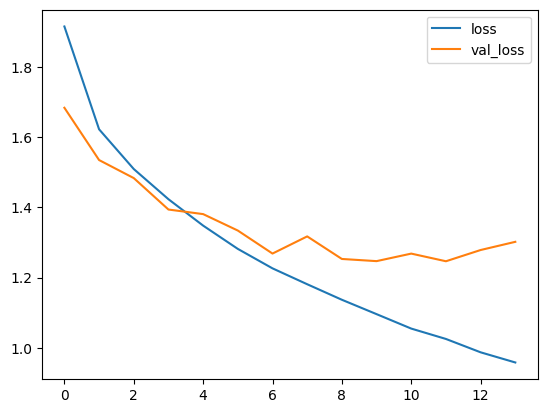

In [38]:
losses[['loss' ,'val_loss']].plot()

<Axes: >

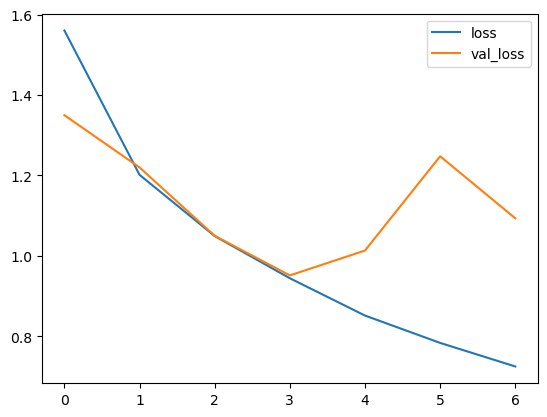

_____________________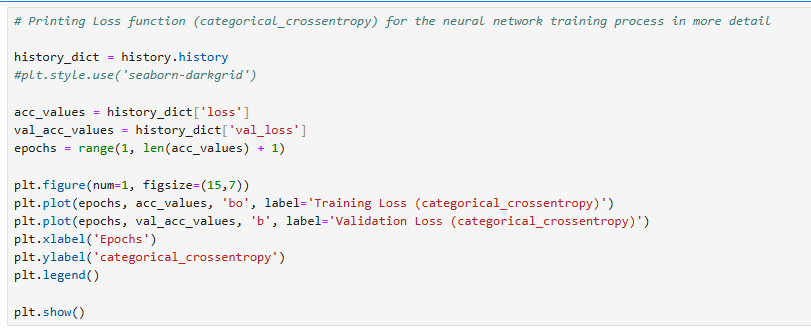

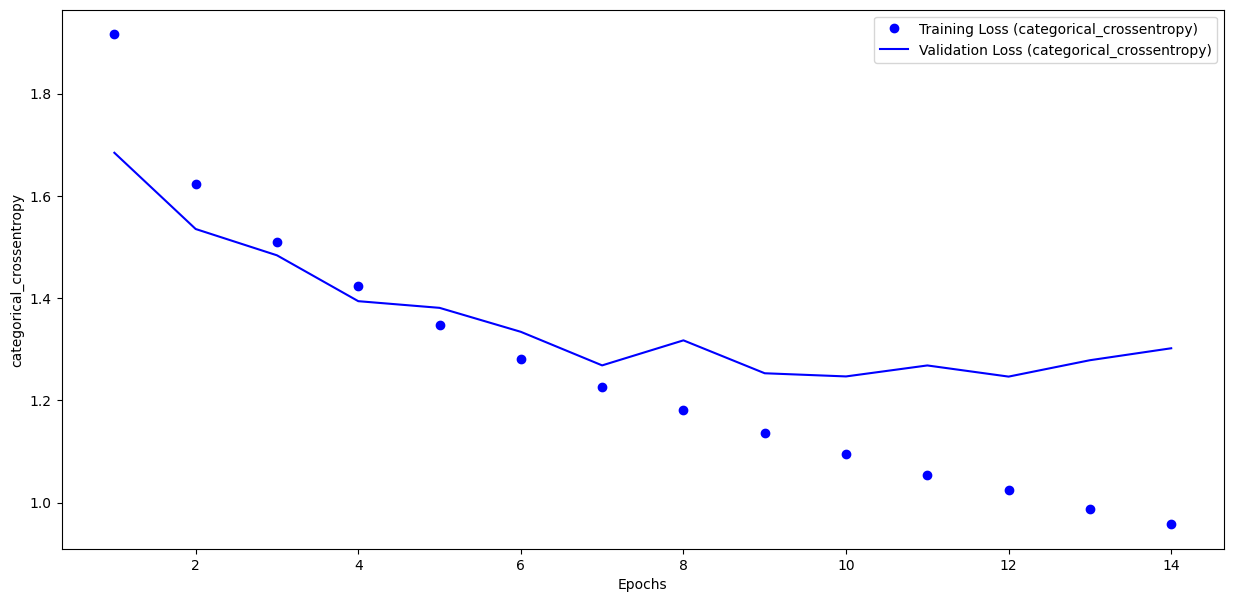

In [40]:
# history_dict =history.history
# acc_values =history_dict['val_loss']
# epochs =range(1,len(acc_values)+1)

# plt.figure(num =1 , figsize =(15,7))
# plt.plot(epochs ,acc_values ,'bo' ,label ='Training Loss (categorical_crossentropy)')
# plt.plot(epochs ,val_acc_values ,'b' ,label ="Validation Loss (categorical_crossentropy)")
# plt.xlabel("Epochs")
# plt.ylabel("categorical_crossentropy")
# plt.legend()
# plt.show()

# Corrected Loss Plot
history_dict = history.history

# Pull the correct loss metrics
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.figure(num=1, figsize=(15,7))
# Plot training loss as blue dots
plt.plot(epochs, loss_values, 'bo', label='Training Loss (categorical_crossentropy)')
# Plot validation loss as a solid blue line
plt.plot(epochs, val_loss_values, 'b', label='Validation Loss (categorical_crossentropy)')

plt.xlabel("Epochs")
plt.ylabel("categorical_crossentropy")
plt.legend()
plt.show()

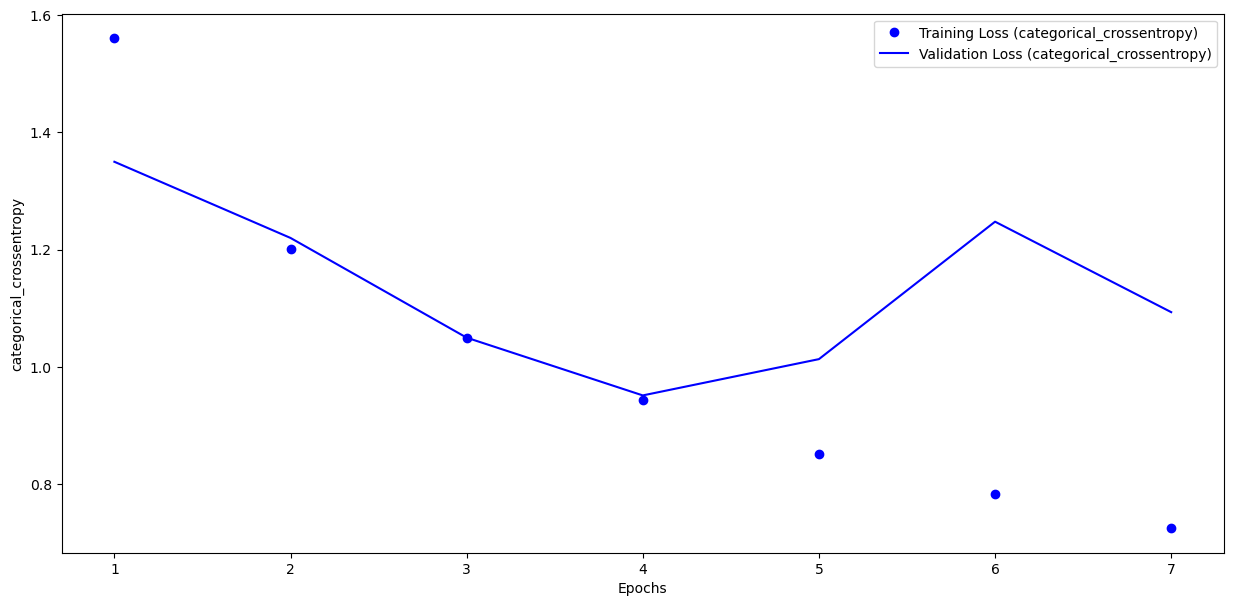

__________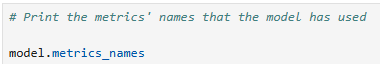

In [41]:
model.metrics_names

['loss', 'accuracy']

['loss', 'compile_metrics']

___________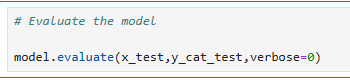

In [42]:
# Evaluate the model

model.evaluate(x_test,y_cat_test,verbose=0)

2026-02-26 11:42:54.890986: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


[1.301875114440918, 0.5738000273704529]

___________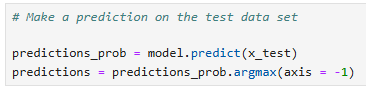

In [43]:
predictions_prob =model.predict(x_test)
predictions=predictions_prob.argmax(axis =-1)

313/313 [==============================] - 2s 6ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


_______________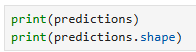

In [44]:
print(predictions)
print(predictions.shape)

[3 8 8 ... 5 4 7]
(10000,)


[3 8 1 ... 5 1 7]
(10000,)


##### You could get the full classification report. 

_____________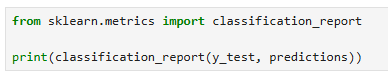

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.71      0.54      0.62      1000
           1       0.66      0.78      0.72      1000
           2       0.53      0.38      0.44      1000
           3       0.35      0.38      0.37      1000
           4       0.50      0.52      0.51      1000
           5       0.46      0.52      0.49      1000
           6       0.54      0.75      0.63      1000
           7       0.66      0.61      0.64      1000
           8       0.67      0.76      0.71      1000
           9       0.78      0.49      0.60      1000

    accuracy                           0.57     10000
   macro avg       0.59      0.57      0.57     10000
weighted avg       0.59      0.57      0.57     10000



              precision    recall  f1-score   support

           0       0.76      0.70      0.73      1000
           1       0.82      0.76      0.79      1000
           2       0.81      0.38      0.52      1000
           3       0.56      0.45      0.50      1000
           4       0.56      0.76      0.64      1000
           5       0.53      0.72      0.61      1000
           6       0.83      0.68      0.75      1000
           7       0.76      0.74      0.75      1000
           8       0.80      0.75      0.77      1000
           9       0.62      0.89      0.73      1000

    accuracy                           0.68     10000
   macro avg       0.70      0.68      0.68     10000
weighted avg       0.70      0.68      0.68     10000



##### You could also get and plot confusion matrix.

https://github.com/matplotlib/matplotlib/issues/14751

______________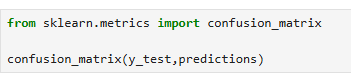

In [46]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test , predictions)

array([[543,  60,  55,  46,  40,  18,  39,  28, 143,  28],
       [ 16, 780,  12,  32,  10,  14,  21,  10,  66,  39],
       [ 58,   9, 380, 105, 127, 115, 141,  40,  20,   5],
       [ 10,  17,  61, 383,  69, 236, 147,  46,  21,  10],
       [ 22,  12,  74,  78, 519,  58, 133,  75,  18,  11],
       [  5,   8,  49, 205,  59, 523,  80,  54,  13,   4],
       [  5,   9,  34,  81,  64,  35, 749,  11,   6,   6],
       [ 14,  15,  18,  74, 102, 113,  32, 615,   6,  11],
       [ 65,  42,  12,  41,  18,  14,  20,   8, 756,  24],
       [ 23, 227,  19,  49,  20,  18,  26,  42,  86, 490]])

array([[697,  33,  12,  17,  33,  20,  11,  15,  84,  78],
       [  8, 762,   1,   9,   1,   7,   7,   3,  18, 184],
       [ 77,   7, 378,  64, 190, 150,  53,  34,  17,  30],
       [ 21,  17,  14, 447, 117, 245,  32,  40,  20,  47],
       [ 14,   2,  11,  34, 760,  47,  19,  83,  12,  18],
       [  8,   4,  11, 106,  71, 717,  13,  40,   8,  22],
       [  7,   9,  21,  76, 107,  51, 684,   9,   8,  28],
       [ 13,   3,   8,  23,  74,  94,   3, 742,   5,  35],
       [ 62,  42,   4,  15,  12,  19,   3,   5, 748,  90],
       [  8,  47,   4,   7,   4,  15,   3,   7,  19, 886]], dtype=int64)

_______________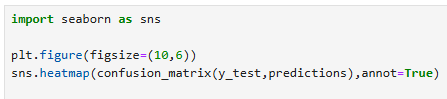

<Axes: >

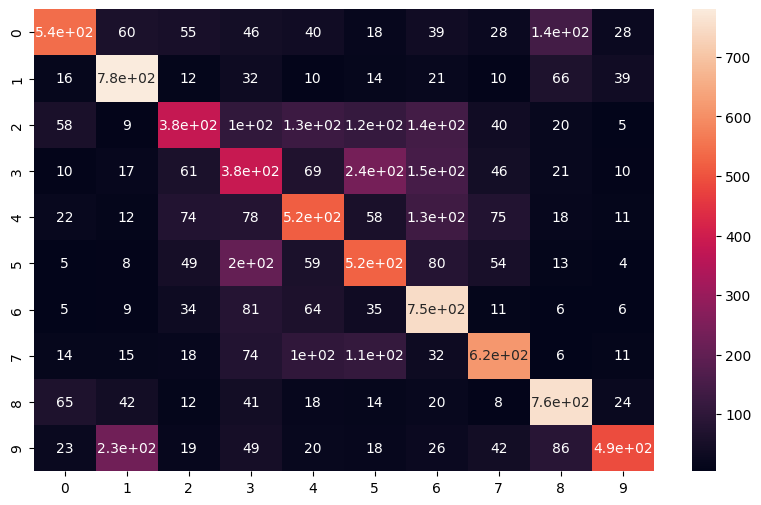

In [49]:
import seaborn as sns
plt.figure(figsize =(10,6))
sns.heatmap(confusion_matrix(y_test ,predictions) , annot= True)

<Axes: >

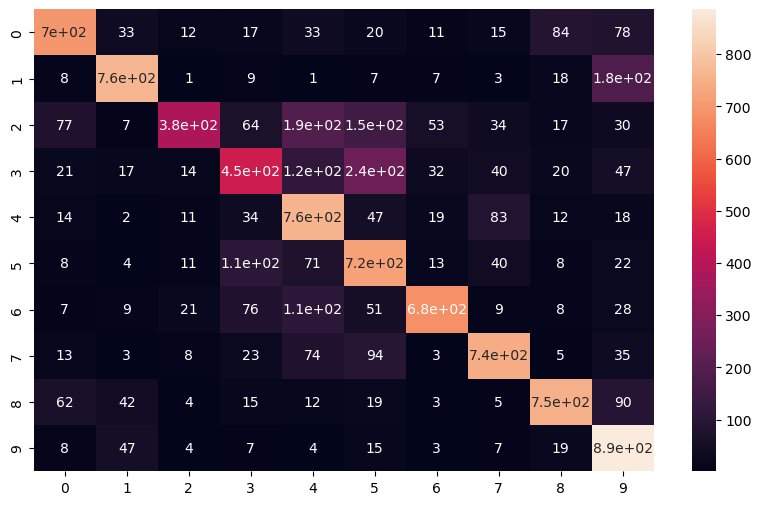

### Following code makes a prediction on specific image.

____________________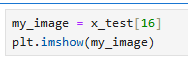

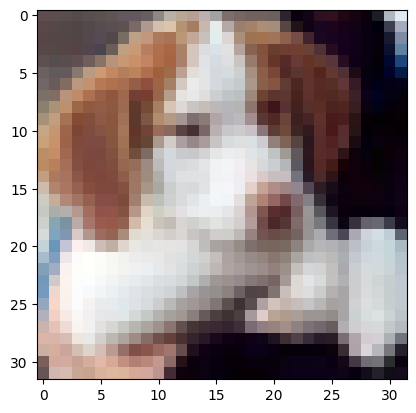

In [50]:
my_image=x_test[16]
plt.imshow(my_image)

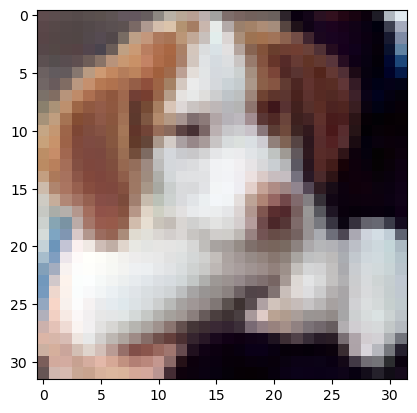

______________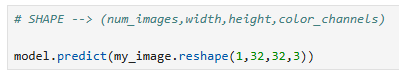

In [51]:
model.predict(my_image.reshape(1,32,32,3))

1/1 [==============================] - 0s 121ms/step


array([[5.8903027e-04, 3.7431097e-04, 5.5309157e-03, 2.6845622e-01,
        4.4022123e-03, 6.9427735e-01, 7.6300758e-03, 1.2938676e-02,
        4.2867921e-03, 1.5143822e-03]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step


array([[1.13101294e-07, 3.55311378e-04, 8.73138470e-06, 8.25540442e-03,
        4.04348157e-07, 9.91317272e-01, 2.81208969e-07, 4.03509657e-05,
        4.70231180e-06, 1.75437362e-05]], dtype=float32)

In [137]:
# Find the highest probability value in the vector above. 
# What output value does it point to?

_______________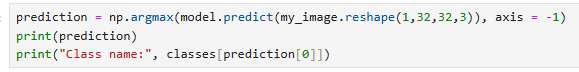

In [52]:
prediction =np.argmax(model.predict(my_image.reshape(1,32,32,3)) ,axis =-1)
print(prediction)
print("Class name:" ,classes[prediction[0]])

1/1 [==============================] - 0s 70ms/step
[5]
Class name: dog


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
[5]
Class name: dog


### Let's use a trained neural network
You can run the following code many times

Note the recognition probabilities for each image

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 3 cells using 'Ctrl' + 'Enter' </h4> </html>

1/1 [==============================] - 0s 71ms/step


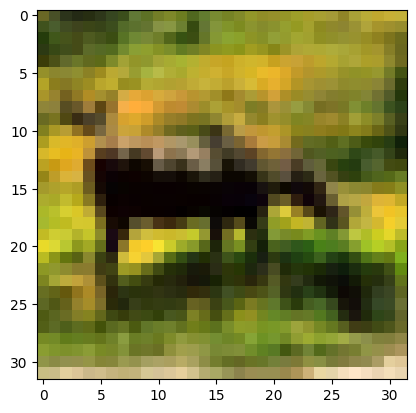

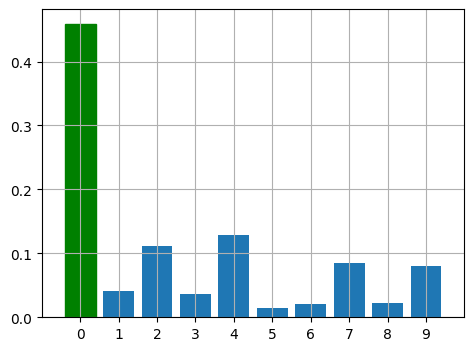

The predicted answer: aircraft 
 Correct answer: deer
['aircraft', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [53]:
from tensorflow.keras.preprocessing.image import array_to_img

# Class names in the CIFAR-10 dataset
classes=['aircraft', 'car', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']

# we take a random element 'random.randint()' from the test sample
# and observe: the neural network will guess or not
index = random.randint(0, x_test.shape[0])
plt.imshow(array_to_img(x_test[index]))

# test image conversion
x = x_test[index]
x = np.expand_dims(x, axis=0)

# start recognition
prediction = model.predict(x)
sample = x

# converting the result from one hot encoding format
ans = np.argmax(prediction)

fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(1, 2, 2)
bar_list = ax.bar(np.arange(10), prediction[0], align='center')
bar_list[ans].set_color('g')
ax.set_xticks(np.arange(10))
ax.set_xlim([-1, 10])
ax.grid('on')

plt.show()

print('The predicted answer: {}'.format((classes[ans])), "\n",
     'Correct answer: {}'.format(classes[y_test[index][0]]) )

print(classes)


# You can run this cell many times, and each time you will get a new picture,
# which this neural network will recognise with the probability indicated on the graph.

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot of the model building code and model's summary

### 2. Please ensure to document in your laboratory logbook a graphical representation depicting the train loss and validation loss trends (4 graphs).

### 3. Based on this analysis, determine the optimal number of epochs for training your model. 

<html> <h2 style="font-style:italic; color:blue;"> Task 2 (Optional): </h2> </html>

#### Evaluate your model for different optimisers available in the Keras. 

https://keras.io/api/optimizers/

- Store the optimisers in an array.
- Use for loop to fit, compile, and  test your model.
- Plot the accuracy vs optimiser


In [54]:
# Create a list containing the names of optimisers (Don't use 'AdamW' and 'Adafactor')
# Create an empty list to store scores

# For every optimiser
   # compile your model
   # fit your model, use epochs=3 for each optimiser (otherwise the training will take a long time)
   # using model.evaluate() find score and append the score in a list

# Plot score vs optimiser 

In [60]:
optimizers=['Nadam', 'SGD' ,'RMSprop' ,'adadelta','Adam', 'Adagrad','Adamax'] #adadelta
Scores=[]


In [61]:
from tensorflow.keras import models

In [62]:
for row in optimizers :
    model_1 =models.load_model('cifar_10epochs.keras')
    early_stop= EarlyStopping(monitor ='val_loss',patience=3)
    model_1.compile(loss='categorical_crossentropy',optimizer=row ,metrics =['accuracy'])
    model_1.fit(x_train,y_cat_train ,epochs =5,validation_data=(x_test,y_cat_test),callbacks =[early_stop])
    Scores.append(model_1.evaluate(x_test,y_cat_test,verbose=0))

Epoch 1/5
1561/1563 [============================>.] - ETA: 0s - loss: 0.9007 - accuracy: 0.6806


KeyboardInterrupt



In [58]:
# screen shot of code CNN network 
#  and table parametrs ,

# accuracy , 4 grahs ,  finf which epoch overfittingh starts

In [59]:
Scores

[]